### Setup & Data Loading

Imports required libraries and loads SAR and DEM metadata for Lake Bogoria. Builds file path lookups for each SAR water mask and DEM tile, and sets up the shared output directory for all plots and CSVs produced by this notebook.

In [ ]:
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage
from pyproj import CRS
import pandas as pd

# PROJECT_ROOT = Path("/home/desy/rift-waters")
region = "bogoria"
sar_df = pd.read_csv("../dataset/bogoria/metadata/bogoria_sar.csv")
dem_df = pd.read_csv("../dataset/bogoria/metadata/bogoria_dem.csv")

# Shared output directory for all plots and CSVs produced by this notebook
ANALYSIS_DIR = Path("../bogoria/analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

image_ids = sar_df["image_id"].tolist()
sar_paths = {}
for image_id in image_ids:
    sar_image_path = str( f"../dataset/{region}/processed/sar_water_mask/{region}_{image_id}.tif")
    sar_paths[image_id] = sar_image_path

dem_tile_paths = [str(Path("../") / p) for p in dem_df["dem_path"].tolist()]
print(f"{len(image_ids)} SAR water masks found for {region}")
print(f"{len(dem_tile_paths)} DEM tiles found for {region}")

119 SAR water masks found for bogoria
120 DEM tiles found for bogoria


### DEM Mosaic

Merges all GLO-30 DEM tiles covering the region into a single mosaic array, in the DEM's native geographic CRS (EPSG:4326).

In [2]:
dem_srcs = [rasterio.open(p) for p in dem_tile_paths]
dem_mosaic, dem_transform = merge(dem_srcs)
dem_crs = dem_srcs[0].crs

print(f"DEM mosaic shape: {dem_mosaic.shape}")
print(f"DEM CRS: {dem_crs}")

for src in dem_srcs:
    src.close()#2

DEM mosaic shape: (1, 781, 590)
DEM CRS: EPSG:4326


### Reproject DEM to a Metric CRS (UTM)

The SAR water masks are in a geographic CRS (EPSG:4326), which isn't suitable for area or volume calculations — pixel size would be in degrees, not meters. This determines the appropriate UTM zone from the DEM's centroid and reprojects the DEM mosaic into it, giving each pixel a real ground area in square meters.

Selected UTM CRS: EPSG:32637
Reprojected DEM shape: (779, 593)
Pixel size: 29.90 x 29.90 m


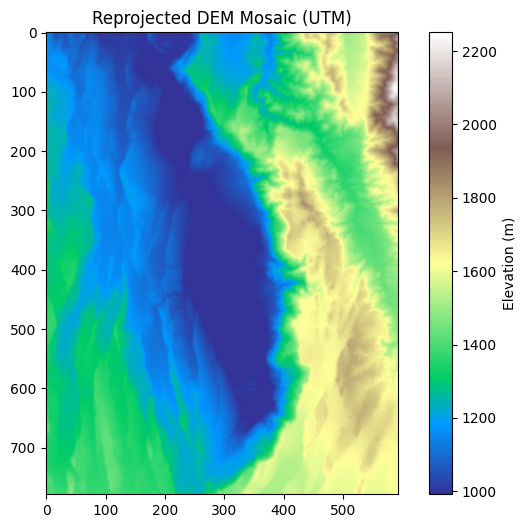

In [ ]:
dem_bounds = rasterio.transform.array_bounds(dem_mosaic.shape[1], dem_mosaic.shape[2], dem_transform)
centroid_lon = (dem_bounds[0] + dem_bounds[2]) / 2
centroid_lat = (dem_bounds[1] + dem_bounds[3]) / 2

utm_zone = int((centroid_lon + 180) / 6) + 1
hemisphere_epsg_base = 32600 if centroid_lat >= 0 else 32700
dst_crs = CRS.from_epsg(hemisphere_epsg_base + utm_zone)
print(f"Selected UTM CRS: {dst_crs}")

dem_transform_new, dem_width_new, dem_height_new = calculate_default_transform(
    dem_crs, dst_crs,
    dem_mosaic.shape[2], dem_mosaic.shape[1],
    *dem_bounds
)

dem_reprojected = np.empty((dem_height_new, dem_width_new), dtype=dem_mosaic.dtype)
reproject(
    source=dem_mosaic[0],
    destination=dem_reprojected,
    src_transform=dem_transform,
    src_crs=dem_crs,
    dst_transform=dem_transform_new,
    dst_crs=dst_crs,
    resampling=Resampling.bilinear
)

print(f"Reprojected DEM shape: {dem_reprojected.shape}")
print(f"Pixel size: {dem_transform_new.a:.2f} x {abs(dem_transform_new.e):.2f} m")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dem_reprojected, cmap="terrain")
ax.set_title("Reprojected DEM Mosaic (UTM)")
plt.colorbar(im, ax=ax, label="Elevation (m)")
plt.savefig(ANALYSIS_DIR / "dem_mosaic_reprojected.png", dpi=150, bbox_inches="tight")
plt.show()#3

### Align SAR Water Masks to the DEM Grid

Resamples each SAR-derived water mask onto the reprojected DEM's pixel grid so both datasets share identical dimensions for direct comparison.

Aligned 119 water masks to DEM grid, shape (779, 593)


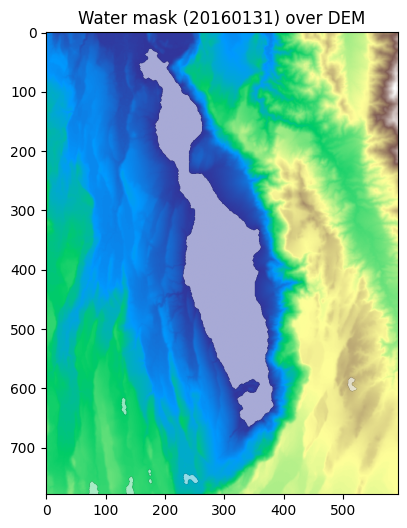

In [4]:
def align_mask_to_dem(mask_path, dst_transform, dst_shape, dst_crs):
    with rasterio.open(mask_path) as src:
        aligned = np.empty(dst_shape, dtype=src.dtypes[0])
        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest  # categorical mask — no interpolation
        )
    return aligned

dem_shape = dem_reprojected.shape

aligned_masks = {}
for image_id, path in sar_paths.items():
    aligned_masks[image_id] = align_mask_to_dem(path, dem_transform_new, dem_shape, dst_crs)

print(f"Aligned {len(aligned_masks)} water masks to DEM grid, shape {dem_shape}")

sample_id = image_ids[0]
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(dem_reprojected, cmap="terrain")
ax.imshow(np.ma.masked_where(aligned_masks[sample_id] == 0, aligned_masks[sample_id]),
          cmap="Blues", alpha=0.6)
ax.set_title(f"Water mask ({sample_id}) over DEM")
plt.savefig(ANALYSIS_DIR / "sample_water_mask_overlay.png", dpi=150, bbox_inches="tight")
plt.show()#4

### Shoreline Extraction & Water Surface Elevation (WSE)

Extracts shoreline (boundary) pixels from each water mask via erosion, samples DEM elevation at those pixels, and takes the median as the estimated water surface elevation (WSE) for that date.

In [11]:
def extract_shoreline(water_mask, erosion_iterations=1):
    water_binary = (water_mask == 1)
    eroded = ndimage.binary_erosion(water_binary, iterations=erosion_iterations)
    return water_binary & ~eroded

def estimate_wse(dem_array, shoreline_mask, percentile=50):
    elevations = dem_array[shoreline_mask]
    elevations = elevations[np.isfinite(elevations)]
    if elevations.size == 0:
        return np.nan
    return np.percentile(elevations, percentile)

wse_results = {}
for image_id, mask in aligned_masks.items():
    shoreline = extract_shoreline(mask)
    wse = estimate_wse(dem_reprojected, shoreline)
    wse_results[image_id] = {
        "wse_m": wse,
        "shoreline_pixel_count": int(shoreline.sum()),
        "water_pixel_count": int((mask == 1).sum())
    }

wse_df = pd.DataFrame.from_dict(wse_results, orient="index").reset_index().rename(columns={"index": "image_id"})
wse_df.head()

,image_id,wse_m,shoreline_pixel_count,water_pixel_count
0,20160131,996.640137,1826,46669
1,20160229,994.969604,1435,44094
2,20160331,996.646973,2139,47474
3,20160430,994.531372,1423,43356
4,20160531,995.094971,1438,44135


### Merge WSE with SAR Metadata

Joins the WSE results with SAR-derived area and perimeter metadata by `image_id` (inner join drops any date missing a water mask), parses the date, and sorts the record chronologically.

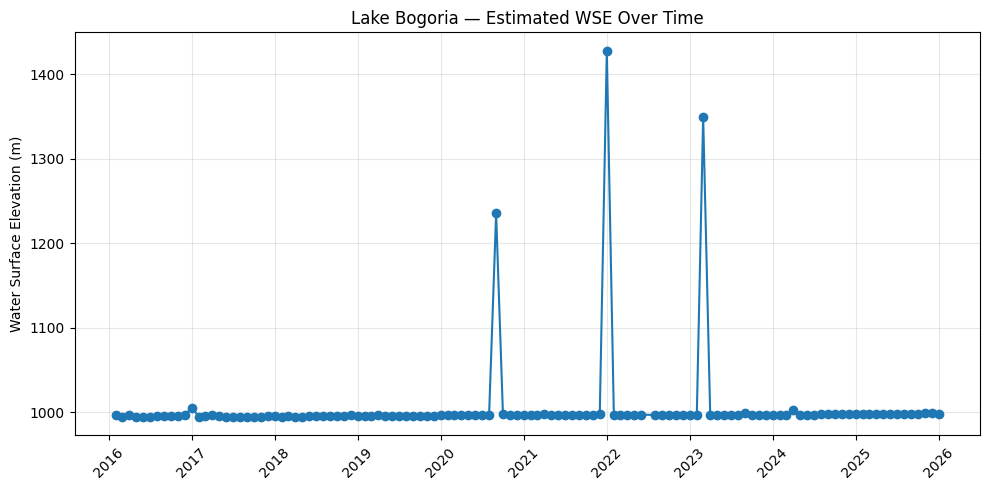

In [6]:
merged_df = wse_df.merge(sar_df, on="image_id", how="inner", suffixes=("", "_sar"))

dropped_ids = set(sar_df["image_id"]) - set(wse_df["image_id"])
if dropped_ids:
    print(f"Dropped {len(dropped_ids)} image_id(s) with no matching water mask: {sorted(dropped_ids)}")

merged_df["date"] = pd.to_datetime(
    merged_df["image_id"].astype(str).str.extract(r"(\d{8})")[0], format="%Y%m%d"
)
merged_df = merged_df.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(merged_df["date"], merged_df["wse_m"], marker="o")
ax.set_ylabel("Water Surface Elevation (m)")
ax.set_title("Lake Bogoria — Estimated WSE Over Time")
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "wse_over_time.png", dpi=150, bbox_inches="tight")
plt.show()#6

### Basin Mask & DEM-Derived Flood Extent

Builds a hydrologically-connected basin mask per date via flood-fill from a lake-interior seed pixel, constrained to elevations below the estimated WSE. Compares the resulting DEM-derived extent against the independent SAR-derived extent as a cross-check.

Using seed pixel: (397, 289)
Pixel area: 893.94 m^2
           image_id  dem_extent_m2  sar_extent_m2    pct_diff
count  1.190000e+02   1.190000e+02   1.190000e+02  119.000000
mean   2.020555e+07   4.494595e+07   4.156829e+07    4.839985
std    2.893431e+04   3.221193e+07   4.168777e+06   48.642659
min    2.016013e+07   3.738888e+07   3.838997e+07   -6.240477
25%    2.018068e+07   3.908244e+07   4.019770e+07   -2.796892
50%    2.020123e+07   4.027897e+07   4.132030e+07   -2.607683
75%    2.023068e+07   4.060481e+07   4.175555e+07   -2.456589
max    2.025123e+07   2.877911e+08   8.202259e+07  397.137431


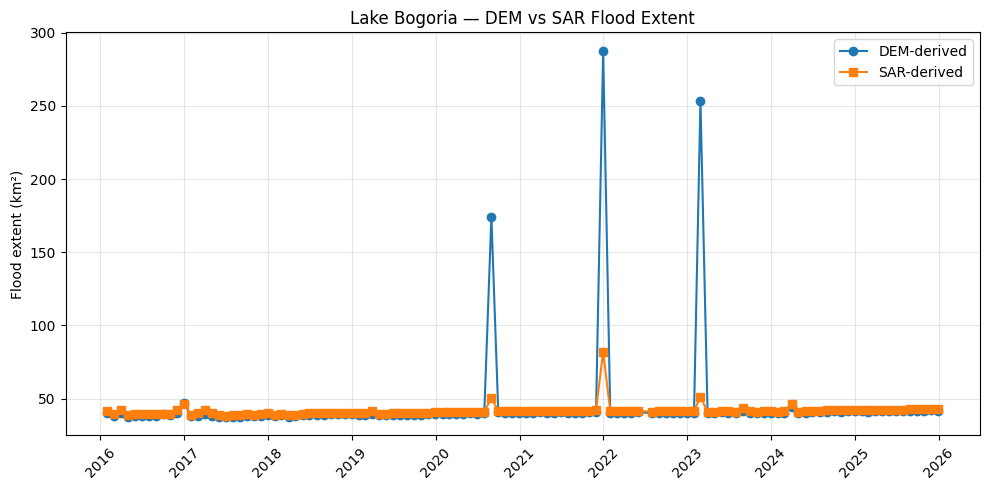

In [ ]:
def get_basin_mask(dem_array, wse, seed_point):
    below_wse = dem_array < wse
    labeled, _ = ndimage.label(below_wse, structure=np.ones((3, 3)))
    seed_label = labeled[seed_point]
    if seed_label == 0:
        return np.zeros_like(below_wse, dtype=bool)
    return labeled == seed_label

sample_water_rows, sample_water_cols = np.where(aligned_masks[sample_id] == 1)
seed_point = (int(np.median(sample_water_rows)), int(np.median(sample_water_cols)))
print(f"Using seed pixel: {seed_point}")

pixel_area_m2 = abs(dem_transform_new.a * dem_transform_new.e)
print(f"Pixel area: {pixel_area_m2:.2f} m^2")

extent_results = []
for _, row in merged_df.iterrows():
    basin_mask = get_basin_mask(dem_reprojected, row["wse_m"], seed_point)
    dem_area_m2 = basin_mask.sum() * pixel_area_m2
    extent_results.append({
        "image_id": row["image_id"],
        "dem_extent_m2": dem_area_m2,
        "sar_extent_m2": row["boundary_area_m2"],
        "pct_diff": 100 * (dem_area_m2 - row["boundary_area_m2"]) / row["boundary_area_m2"]
    })

extent_df = pd.DataFrame(extent_results)
print(extent_df.describe())

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(merged_df["date"], extent_df["dem_extent_m2"] / 1e6, marker="o", label="DEM-derived")
# ax.plot(merged_df["date"], extent_df["sar_extent_m2"] / 1e6, marker="s", label="SAR-derived")
# ax.set_ylabel("Flood extent (km²)")
# ax.legend()
# ax.set_title("Lake Bogoria — DEM vs SAR Flood Extent")
# ax.grid(alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.savefig(ANALYSIS_DIR / "dem_vs_sar_extent.png", dpi=150, bbox_inches="tight")
# plt.show()#7

### Expansion Volume (All-Time Dry-Land Baseline)

Estimates flood expansion volume per date, using the union of all basin masks across the record as the "dry land" baseline. Superseded later by the outlier-excluded and baseline-date versions further down.

     image_id       date       wse_m  expansion_volume_m3  \
0    20160131 2016-01-31  996.640137                  0.0   
1    20160229 2016-02-29  994.969604                  0.0   
2    20160331 2016-03-31  996.646973                  0.0   
3    20160430 2016-04-30  994.531372                  0.0   
4    20160531 2016-05-31  995.094971                  0.0   
..        ...        ...         ...                  ...   
114  20250831 2025-08-31  998.661377                  0.0   
115  20250930 2025-09-30  998.641479                  0.0   
116  20251031 2025-10-31  998.824158                  0.0   
117  20251130 2025-11-30  999.376709                  0.0   
118  20251231 2025-12-31  998.671631                  0.0   

     expansion_pixel_count  
0                        0  
1                        0  
2                        0  
3                        0  
4                        0  
..                     ...  
114                      0  
115                      0  
116   

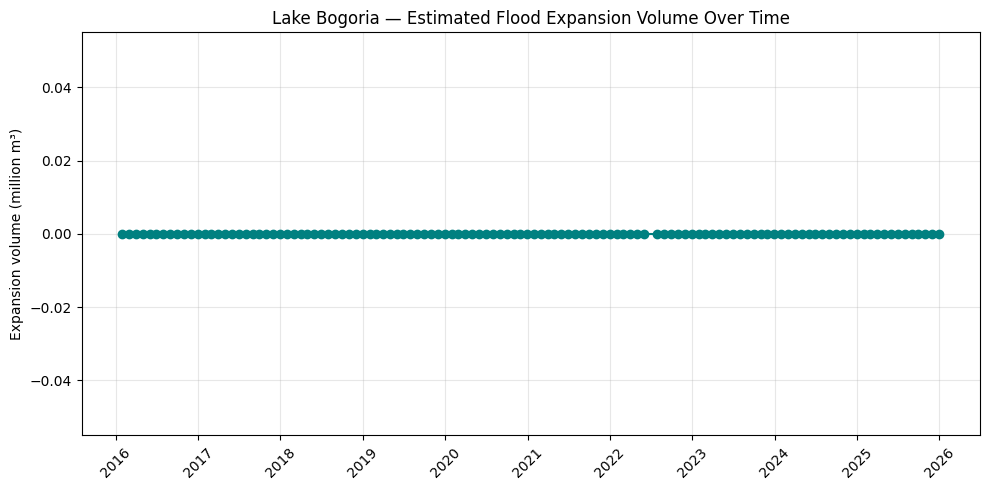

In [8]:
def get_dry_land_baseline(dem_array, basin_masks_over_time):
    ever_wet = np.zeros_like(basin_masks_over_time[0], dtype=bool)
    for mask in basin_masks_over_time:
        ever_wet |= mask
    return ~ever_wet

def estimate_volume(dem_array, basin_mask, wse, dry_land_mask, pixel_area_m2):
    expansion_mask = basin_mask & dry_land_mask
    depths = np.clip(wse - dem_array[expansion_mask], 0, None)
    return np.sum(depths) * pixel_area_m2, expansion_mask.sum()

basin_masks_by_date = [get_basin_mask(dem_reprojected, row["wse_m"], seed_point) for _, row in merged_df.iterrows()]
dry_land_baseline = get_dry_land_baseline(dem_reprojected, basin_masks_by_date)

volume_results = []
for i, row in merged_df.iterrows():
    volume_m3, expansion_px = estimate_volume(
        dem_reprojected, basin_masks_by_date[i], row["wse_m"], dry_land_baseline, pixel_area_m2
    )
    volume_results.append({
        "image_id": row["image_id"], "date": row["date"],
        "wse_m": row["wse_m"], "expansion_volume_m3": volume_m3,
        "expansion_pixel_count": expansion_px
    })

volume_df = pd.DataFrame(volume_results)
print(volume_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(volume_df["date"], volume_df["expansion_volume_m3"] / 1e6, marker="o", color="teal")
ax.set_ylabel("Expansion volume (million m³)")
ax.set_title("Lake Bogoria — Estimated Flood Expansion Volume Over Time")
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "expansion_volume_alltime_baseline.png", dpi=150, bbox_inches="tight")
plt.show()#8

### Initial Summary Export

First-pass summary table combining WSE, extent, and volume results, exported for inspection before outlier flagging was introduced.

### Outlier Detection

Flags dates whose SAR boundary perimeter deviates far from the typical pattern (>2x the median), which correspond to WSE estimation failures from misclassified or noisy shoreline pixels.

### Volume calculation

Compute basin masks for all dates

In [9]:
### Volume Calculation

# Compute basin masks for all dates
basin_masks = [get_basin_mask(dem_reprojected, row["wse_m"], seed_point) for _, row in merged_df.iterrows()]

# Define dry-land baseline as union of all basin masks
dry_land_baseline = get_dry_land_baseline(dem_reprojected, basin_masks)
print(f"Dry-land baseline pixel count: {dry_land_baseline.sum()} "
      f"({dry_land_baseline.sum() * pixel_area_m2 / 1e6:.2f} km² never observed as water)")

volume_results = []
for i, row in merged_df.iterrows():
    volume_m3, expansion_px = estimate_volume(
        dem_reprojected, basin_masks[i], row["wse_m"], dry_land_baseline, pixel_area_m2
    )
    volume_results.append({
        "image_id": row["image_id"], "date": row["date"],
        "wse_m": row["wse_m"], "expansion_volume_m3": volume_m3,
        "expansion_pixel_count": expansion_px
    })

volume_df = pd.DataFrame(volume_results)
print(volume_df.describe())

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(volume_df["date"], volume_df["expansion_volume_m3"] / 1e6, marker="o", color="teal")
# ax.set_ylabel("Expansion volume (million m³)")
# ax.set_xlabel("Date")
# ax.set_title("Lake Bogoria — Expansion Volume Over Time")
# ax.grid(alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.savefig(ANALYSIS_DIR / "expansion_volume.png", dpi=150, bbox_inches="tight")
# #plt.show()

Dry-land baseline pixel count: 140010 (125.16 km² never observed as water)
           image_id                           date        wse_m  \
count  1.190000e+02                            119   119.000000   
mean   2.020555e+07  2021-01-09 17:20:40.336134400  1005.411621   
min    2.016013e+07            2016-01-31 00:00:00   994.388184   
25%    2.018068e+07            2018-07-15 12:00:00   996.027679   
50%    2.020123e+07            2020-12-31 00:00:00   996.971191   
75%    2.023068e+07            2023-07-15 12:00:00   997.365601   
max    2.025123e+07            2025-12-31 00:00:00  1427.749512   
std    2.893431e+04                            NaN    55.122151   

       expansion_volume_m3  expansion_pixel_count  
count                119.0                  119.0  
mean                   0.0                    0.0  
min                    0.0                    0.0  
25%                    0.0                    0.0  
50%                    0.0                    0.0  
75%      

### Final Summary Table & Export

Combines WSE, extent, and volume results into one table with the outlier flag retained for transparency, plots a 3-panel time series, and exports the summary CSV.

In [12]:
summary_df = merged_df[["image_id", "date", "wse_m", "boundary_area_m2", "boundary_perimeter_m"
                         ]].merge(
    extent_df[["image_id", "dem_extent_m2", "pct_diff"]], on="image_id"
).merge(
    volume_df[["image_id", "expansion_volume_m3", "expansion_pixel_count"]], on="image_id", how="left"
)
# Outlier rows won't have a volume_df match (excluded above) — keep explicit rather than a silent NaN
summary_df["expansion_volume_m3"] = summary_df["expansion_volume_m3"].fillna(np.nan)
summary_df["excluded_from_volume_calc"] = summary_df["is_outlier"]

print(summary_df)

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

clean_mask = ~summary_df["is_outlier"]

axes[0].plot(summary_df.loc[clean_mask, "date"], summary_df.loc[clean_mask, "wse_m"], marker="o", color="steelblue")
axes[0].scatter(summary_df.loc[~clean_mask, "date"], summary_df.loc[~clean_mask, "wse_m"], color="red", zorder=5, label="Outlier")
axes[0].set_ylabel("WSE (m)")
axes[0].set_title("Lake Bogoria — Water Surface Elevation")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(summary_df.loc[clean_mask, "date"], summary_df.loc[clean_mask, "dem_extent_m2"], marker="o", label="DEM-derived", color="darkorange")
axes[1].plot(summary_df["date"], summary_df["boundary_area_m2"] / 1e6, marker="s", label="SAR-derived", color="green")
axes[1].scatter(summary_df.loc[~clean_mask, "date"], summary_df.loc[~clean_mask, "dem_extent_m2"], color="red", zorder=5)
axes[1].set_ylabel("Extent (km²)")
axes[1].set_title("Flood Extent — DEM vs SAR (outliers in red)")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(summary_df.loc[clean_mask, "date"], summary_df.loc[clean_mask, "expansion_volume_m3"] , marker="o", color="teal")
axes[2].set_ylabel("Volume (million m³)")
axes[2].set_xlabel("Date")
axes[2].set_title("Estimated Expansion Volume (outlier dates excluded)")
axes[2].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "summary_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

output_path = ANALYSIS_DIR / f"{region}_expansion_summary.csv"
summary_df.to_csv(output_path, index=False)
print(f"\nSaved summary to: {output_path}")
print(f"Flagged {summary_df['is_outlier'].sum()} outlier date(s) — retained in CSV but excluded from volume calc")

KeyError: 'is_outlier'

### Expansion Evidence: Trends in Extent & WSE

Computes linear trends (rate of change per year) for lake surface area and WSE, and plots cumulative surface area change relative to the earliest observed date — the clearest visual evidence of expansion.

Extent trend: 361,927 m²/year  (R²=0.064, p=0.0056)
WSE trend:    1.3920 m/year        (R²=0.005, p=0.4274)


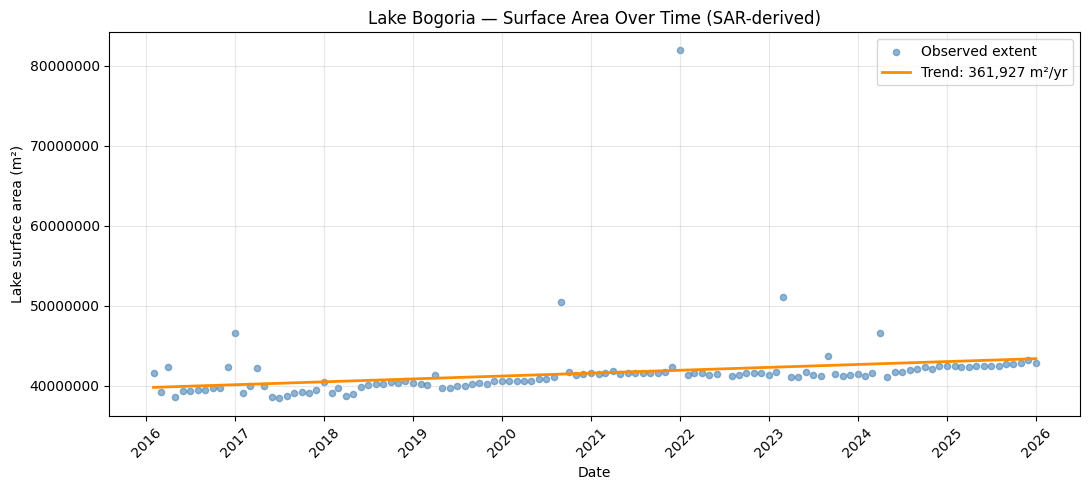

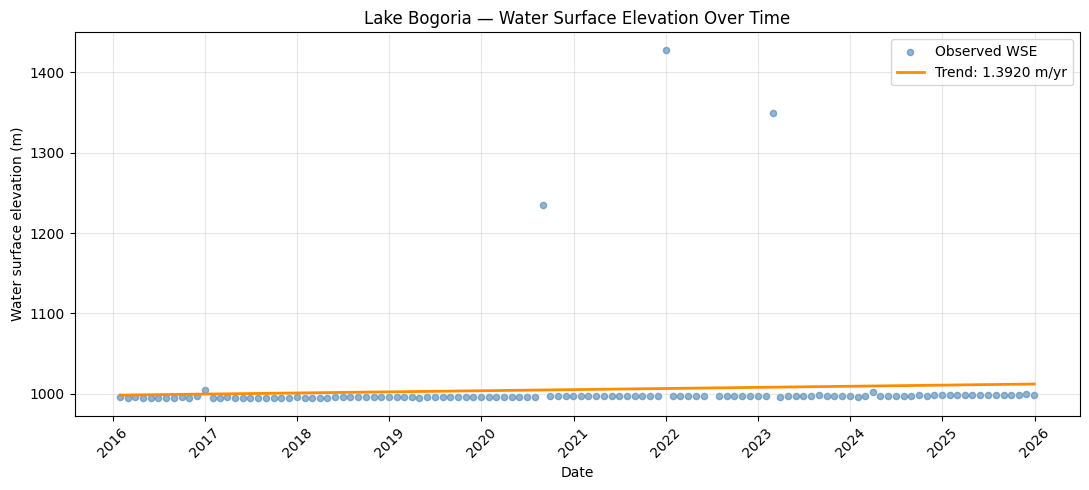

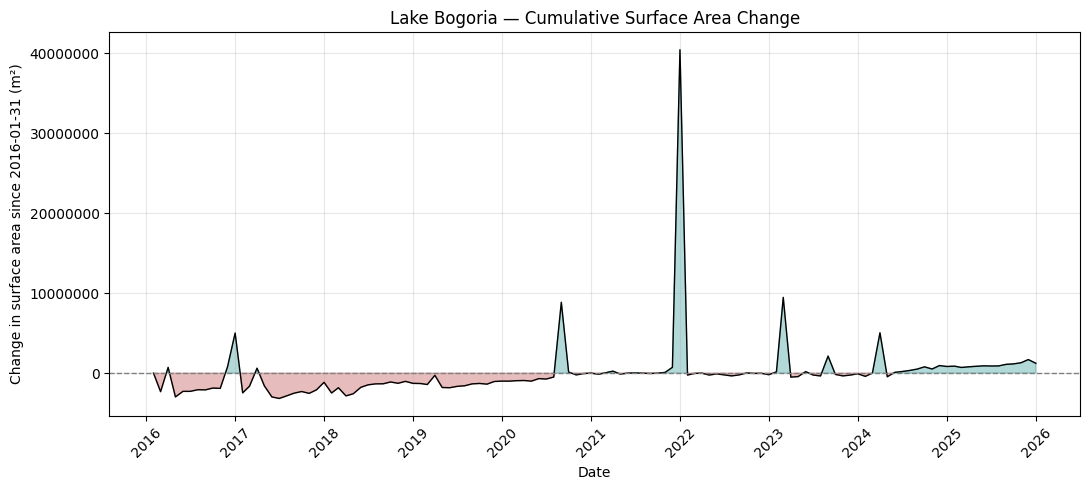

In [ ]:
### Expansion Evidence: Trends in Extent & WSE

from scipy import stats

plot_df = merged_df.copy()
plot_df["days_since_start"] = (plot_df["date"] - plot_df["date"].min()).dt.days
plot_df["years_since_start"] = plot_df["days_since_start"] / 365.25

slope_extent, intercept_extent, r_extent, p_extent, _ = stats.linregress(
    plot_df["years_since_start"], plot_df["boundary_area_m2"]
)
trend_extent = intercept_extent + slope_extent * plot_df["years_since_start"]

slope_wse, intercept_wse, r_wse, p_wse, _ = stats.linregress(
    plot_df["years_since_start"], plot_df["wse_m"]
)
trend_wse = intercept_wse + slope_wse * plot_df["years_since_start"]

print(f"Extent trend: {slope_extent:,.0f} m²/year  (R²={r_extent**2:.3f}, p={p_extent:.4f})")
print(f"WSE trend:    {slope_wse:.4f} m/year        (R²={r_wse**2:.3f}, p={p_wse:.4f})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(plot_df["date"], plot_df["boundary_area_m2"], s=20, color="steelblue", alpha=0.6, label="Observed extent")
ax.plot(plot_df["date"], trend_extent, color="darkorange", linewidth=2,
        label=f"Trend: {slope_extent:,.0f} m²/yr")
ax.set_ylabel("Lake surface area (m²)")
ax.set_xlabel("Date")
ax.set_title("Lake Bogoria — Surface Area Over Time (SAR-derived)")
ax.ticklabel_format(axis="y", style="plain")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "surface_area_trend.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(plot_df["date"], plot_df["wse_m"], s=20, color="steelblue", alpha=0.6, label="Observed WSE")
ax.plot(plot_df["date"], trend_wse, color="darkorange", linewidth=2,
        label=f"Trend: {slope_wse:.4f} m/yr")
ax.set_ylabel("Water surface elevation (m)")
ax.set_xlabel("Date")
ax.set_title("Lake Bogoria — Water Surface Elevation Over Time")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "wse_trend.png", dpi=150, bbox_inches="tight")
plt.show()

baseline_extent = plot_df["boundary_area_m2"].iloc[0]
plot_df["cumulative_expansion_m2"] = plot_df["boundary_area_m2"] - baseline_extent

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(plot_df["date"], plot_df["cumulative_expansion_m2"], 0,
                 where=(plot_df["cumulative_expansion_m2"] >= 0), color="teal", alpha=0.3, interpolate=True)
ax.fill_between(plot_df["date"], plot_df["cumulative_expansion_m2"], 0,
                 where=(plot_df["cumulative_expansion_m2"] < 0), color="firebrick", alpha=0.3, interpolate=True)
ax.plot(plot_df["date"], plot_df["cumulative_expansion_m2"], color="black", linewidth=1)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel(f"Change in surface area since {plot_df['date'].iloc[0].date()} (m²)")
ax.set_xlabel("Date")
ax.set_title("Lake Bogoria — Cumulative Surface Area Change")
ax.ticklabel_format(axis="y", style="plain")
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "cumulative_surface_area_change.png", dpi=150, bbox_inches="tight")
plt.show()

### Volume Diagnostic Check

Checks whether expansion volume values are truly zero or just hidden by display rounding, to diagnose why the all-time-union baseline showed no variation.

In [ ]:
pd.set_option("display.float_format", lambda x: f"{x:.6e}")

volume_check = summary_df[~summary_df["is_outlier"]][["image_id", "date", "wse_m", "expansion_volume_m3", "expansion_pixel_count"]].copy()
print(volume_check)

pd.reset_option("display.float_format")

print(f"\nVolume stats:")
print(f"  min:  {volume_check['expansion_volume_m3'].min():.6e}")
print(f"  max:  {volume_check['expansion_volume_m3'].max():.6e}")
print(f"  mean: {volume_check['expansion_volume_m3'].mean():.6e}")
print(f"  std:  {volume_check['expansion_volume_m3'].std():.6e}")
print(f"  non-zero count: {(volume_check['expansion_volume_m3'] != 0).sum()} / {len(volume_check)}")#14

     image_id       date        wse_m  expansion_volume_m3  \
0    20160131 2016-01-31 9.966401e+02         0.000000e+00   
1    20160229 2016-02-29 9.949696e+02         0.000000e+00   
2    20160331 2016-03-31 9.966470e+02         0.000000e+00   
3    20160430 2016-04-30 9.945314e+02         0.000000e+00   
4    20160531 2016-05-31 9.950950e+02         0.000000e+00   
..        ...        ...          ...                  ...   
114  20250831 2025-08-31 9.986614e+02         0.000000e+00   
115  20250930 2025-09-30 9.986415e+02         0.000000e+00   
116  20251031 2025-10-31 9.988242e+02         0.000000e+00   
117  20251130 2025-11-30 9.993767e+02         0.000000e+00   
118  20251231 2025-12-31 9.986716e+02         0.000000e+00   

     expansion_pixel_count  
0             0.000000e+00  
1             0.000000e+00  
2             0.000000e+00  
3             0.000000e+00  
4             0.000000e+00  
..                     ...  
114           0.000000e+00  
115           0.000000e

### Volume Relative to Earliest Baseline Date

Redefines the dry-land reference as the basin extent of the earliest observed (clean) date, rather than the all-time union. This produces a volume metric that actually varies — showing growth or shrinkage relative to the 2016 baseline.

Baseline date: 2016-01-31
Baseline basin pixel count: 44604 (39.87 km²)

Non-zero count: 64 / 114
           image_id                           date       wse_m  \
count  1.140000e+02                            114  114.000000   
mean   2.020541e+07  2021-01-03 12:12:37.894736896  996.698311   
min    2.016013e+07            2016-01-31 00:00:00  994.388184   
25%    2.018066e+07            2018-07-07 18:00:00  996.001144   
50%    2.020118e+07            2020-12-15 12:00:00  996.960693   
75%    2.023071e+07            2023-07-23 06:00:00  997.282394   
max    2.025123e+07            2025-12-31 00:00:00  999.376709   
std    2.898724e+04                            NaN    1.107679   

       expansion_volume_m3  expansion_pixel_count  
count         1.140000e+02             114.000000  
mean          3.305073e+05             520.701754  
min           0.000000e+00               0.000000  
25%           0.000000e+00               0.000000  
50%           9.415064e+04             439.5000

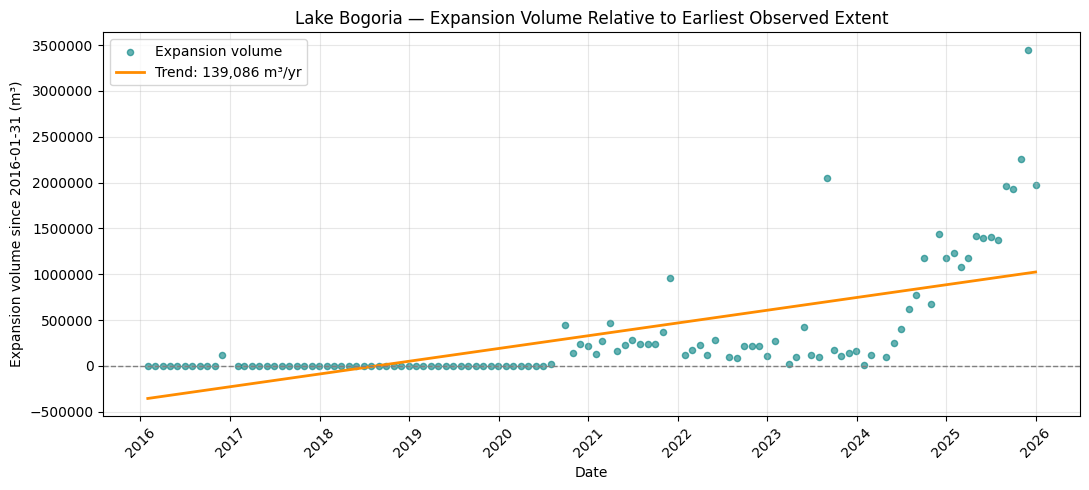

In [ ]:
baseline_basin_mask = basin_masks_clean[0]
baseline_date = clean_df["date"].iloc[0]
print(f"Baseline date: {baseline_date.date()}")
print(f"Baseline basin pixel count: {baseline_basin_mask.sum()} ({baseline_basin_mask.sum() * pixel_area_m2 / 1e6:.2f} km²)")

dry_relative_to_baseline = ~baseline_basin_mask

volume_results = []
for i, row in clean_df.iterrows():
    volume_m3, expansion_px = estimate_volume(
        dem_reprojected, basin_masks_clean[i], row["wse_m"], dry_relative_to_baseline, pixel_area_m2
    )
    volume_results.append({
        "image_id": row["image_id"], "date": row["date"],
        "wse_m": row["wse_m"],
        "expansion_volume_m3": volume_m3,
        "expansion_pixel_count": expansion_px
    })

volume_df = pd.DataFrame(volume_results)
print(f"\nNon-zero count: {(volume_df['expansion_volume_m3'] != 0).sum()} / {len(volume_df)}")
print(volume_df.describe())

volume_df["years_since_start"] = (volume_df["date"] - volume_df["date"].min()).dt.days / 365.25
slope_vol, intercept_vol, r_vol, p_vol, _ = stats.linregress(volume_df["years_since_start"], volume_df["expansion_volume_m3"])
trend_vol = intercept_vol + slope_vol * volume_df["years_since_start"]
print(f"\nVolume trend: {slope_vol:,.0f} m³/year  (R²={r_vol**2:.3f}, p={p_vol:.4f})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(volume_df["date"], volume_df["expansion_volume_m3"], s=20, color="teal", alpha=0.6, label="Expansion volume")
ax.plot(volume_df["date"], trend_vol, color="darkorange", linewidth=2, label=f"Trend: {slope_vol:,.0f} m³/yr")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel(f"Expansion volume since {baseline_date.date()} (m³)")
ax.set_xlabel("Date")
ax.set_title("Lake Bogoria — Expansion Volume Relative to Earliest Observed Extent")
ax.ticklabel_format(axis="y", style="plain")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "expansion_volume_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()#15